# Bone Marrow Dataset Cleaning

In [1]:
library(devtools)
library(hise)
library(tidyverse)
library(purrr)
library(vcd)
library(OlinkAnalyze)
library(lme4)
library(Matrix)
library(vcd)
library(ggpubr)
source('../00-utilities/functions/00_functions_data_loading.R')
file.sources <- list.files(
    path = "./ndmmFH1_helper_functions", 
    pattern = "\\.R$", full.names = TRUE
)
file.sources
# Source each R file
invisible(sapply(file.sources, source))

Loading required package: usethis

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: grid

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loading required package: data.table


Attaching package: ‘data.table’


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘pac

[1] "./ndmmFH1_helper_functions/data_crud.R" 
[2] "./ndmmFH1_helper_functions/data_manip.R"
[3] "./ndmmFH1_helper_functions/data_vis.R"  
[4] "./ndmmFH1_helper_functions/misc.R"      
[5] "./ndmmFH1_helper_functions/static.R"

## Load Files

In [3]:
olink_bmif <- fread('../../data/olink/Olink_BM_with_hise_descriptors_08-18-2025.csv', data.table = F)
# Remove first column
olink_bmif = olink_bmif[,-1]

# Overview of BM Columns

### BM SampleID, SampleType and Sample Format

#### SampleID

BM SampleID seem to have BMIF and a number per subject followed by a serial number. The last part, 001/003 represents Sample Types (IGdepleted vs not). Encoded in the SampleID is also control samples (all starting with "CONTROL_SAMPLE_US_CS_AS_") and supernatant samples (all starting with "SUP"). 
Other samples all start with BMIF, encoding BM pellet samples (in contrast to the supernatants). The controls in sampleID are spread across all PllateIDdata and have no subject. The subject AC1003 is normal bone marrow control, whereas these controls are plate controls. 


In [6]:
unique(sort(olink_bmif$SampleID))

[1] "BMIF02087-001-001"            "BMIF02087-001-003"           
  [3] "BMIF02442-001-001"            "BMIF02442-001-003"           
  [5] "BMIF02598-001-001"            "BMIF02598-001-003"           
  [7] "BMIF02600-001-001"            "BMIF02600-001-003"           
  [9] "BMIF02603-001-001"            "BMIF02603-001-003"           
 [11] "BMIF02604-001-001"            "BMIF02604-001-003"           
 [13] "BMIF02605-001-001"            "BMIF02605-001-003"           
 [15] "BMIF02611-001-001"            "BMIF02611-001-003"           
 [17] "BMIF02612-001-001"            "BMIF02612-001-003"           
 [19] "BMIF02613-001-001"            "BMIF02613-001-003"           
 [21] "BMIF02617-001-001"            "BMIF02617-001-003"           
 [23] "BMIF02618-001-001"            "BMIF02618-001-003"           
 [25] "BMIF04431-001-001"            "BMIF04431-001-003"           
 [27] "BMIF04434-001-001"            "BMIF04434-001-003"           
 [29] "BMIF04435-001-001"            "BMIF04435-001-003"           
 [31] "BMIF04436-001-001"            "BMIF04436-001-003"           
 [33] "BMIF04437-001-001"            "BMIF04437-001-003"           
 [35] "BMIF04707-001-001"            "BMIF04707-001-003"           
 [37] "BMIF04748-001-001"            "BMIF04748-001-003"           
 [39] "BMIF04750-001-001"            "BMIF04750-001-003"           
 [41] "BMIF04751-001-001"            "BMIF04751-001-003"           
 [43] "BMIF04752-001-001"            "BMIF04752-001-003"           
 [45] "BMIF04753-001-001"            "BMIF04753-001-003"           
 [47] "BMIF04754-001-001"            "BMIF04754-001-003"           
 [49] "BMIF04755-001-001"            "BMIF04755-001-003"           
 [51] "BMIF04756-001-001"            "BMIF04756-001-003"           
 [53] "BMIF04757-001-001"            "BMIF04757-001-003"           
 [55] "BMIF04961-001-001"            "BMIF04961-001-003"           
 [57] "BMIF04962-001-001"            "BMIF04962-001-003"           
 [59] "BMIF04963-001-001"            "BMIF04963-001-003"           
 [61] "BMIF04964-001-001"            "BMIF04964-001-003"           
 [63] "BMIF04965-001-001"            "BMIF04965-001-003"           
 [65] "BMIF04966-001-001"            "BMIF04966-001-003"           
 [67] "BMIF04967-001-001"            "BMIF04967-001-003"           
 [69] "BMIF04968-001-001"            "BMIF04968-001-003"           
 [71] "BMIF04969-001-001"            "BMIF04969-001-003"           
 [73] "BMIF04970-001-001"            "BMIF04970-001-003"           
 [75] "BMIF04994-001-001"            "BMIF04994-001-003"           
 [77] "BMIF04996-001-001"            "BMIF04996-001-003"           
 [79] "BMIF04998-002-001"            "BMIF04998-002-003"           
 [81] "BMIF04999-001-001"            "BMIF04999-001-003"           
 [83] "BMIF06062-028-001"            "BMIF06062-028-003"           
 [85] "BMIF06062-028-004"            "BMIF06062-028-005"           
 [87] "BMIF06062-028-006"            "BMIF06062-028-007"           
 [89] "BMIF06062-028-008"            "BMIF06062-028-009"           
 [91] "BMIF06062-029-001"            "BMIF06062-029-003"           
 [93] "BMIF06062-031-001"            "BMIF06062-031-003"           
 [95] "BMIF06062-032-001"            "BMIF06062-032-003"           
 [97] "BMIF06062-033-001"            "BMIF06062-033-003"           
 [99] "BMIF06062-036-001"            "BMIF06062-036-003"           
[101] "BMIF06062-036-004"            "BMIF06062-036-005"           
[103] "BMIF06062-036-006"            "BMIF06062-036-007"           
[105] "CONTROL_SAMPLE_US_CS_AS_3-1"  "CONTROL_SAMPLE_US_CS_AS_3-10"
[107] "CONTROL_SAMPLE_US_CS_AS_3-11" "CONTROL_SAMPLE_US_CS_AS_3-12"
[109] "CONTROL_SAMPLE_US_CS_AS_3-2"  "CONTROL_SAMPLE_US_CS_AS_3-3" 
[111] "CONTROL_SAMPLE_US_CS_AS_3-4"  "CONTROL_SAMPLE_US_CS_AS_3-5" 
[113] "CONTROL_SAMPLE_US_CS_AS_3-6"  "CONTROL_SAMPLE_US_CS_AS_3-7" 
[115] "CONTROL_SAMPLE_US_CS_AS_3-8"  "CONTROL_SAMPLE_US_CS_AS_3-9" 
[117] "SUP02419-001-001"             "SUP02419-001-003"   

AS expected, the control samples are spread out across plates. 

In [7]:
tmp <- olink_bmif[grep("CONTROL", olink_bmif$SampleID),]
table(tmp$PlateID)


Q-11665_SS230887 Q-11665_SS230888 Q-11665_SS230889 Q-11665_SS230890 
            1472             1472             1470             1470 
Q-11665_SS230928 Q-11665_SS230929 
            2944             2944 

#### BM SampleType (different from `Sample Type`)

SampleType indicates whether the sample is control or sample and have no missing values. 

All samples that are indicated to be control is from a SampleID that starts with "CONTROL" (not shown). These are not the normal bone marrow samples but rather plate controls for intensity normalisation. 

It will be discarded in favor of is_plate_control which it is one-to-one with. 

In [8]:
table(olink_bmif$SampleType, useNA="always")
table(olink_bmif$SampleType, olink_bmif$is_technical_control)
olink_bmif <- olink_bmif[,!colnames(olink_bmif) %in% 'SampleType']
dim(olink_bmif)


CONTROL  SAMPLE    <NA> 
  11772  488538       0 

         
           FALSE   TRUE
  CONTROL      0  11772
  SAMPLE  488538      0

[1] 500310     36

#### Sample Format
All biological sample types are labeled as BMIF, and the controls are left as NAs

In [9]:
table(olink_bmif$SampleFormat,olink_bmif$is_technical_control, useNA = 'always')

      
        FALSE   TRUE   <NA>
  BMIF 488538      0      0
  <NA>      0  11772      0

### BM MissingFreq

MissingFreq is standard to the Olink format and indicates the frequency of samples with NPX values below LOD for a certain Assay. 

MissingFreq is constant per assay. 

[1] "MissingFreq is constant per assay: TRUE"

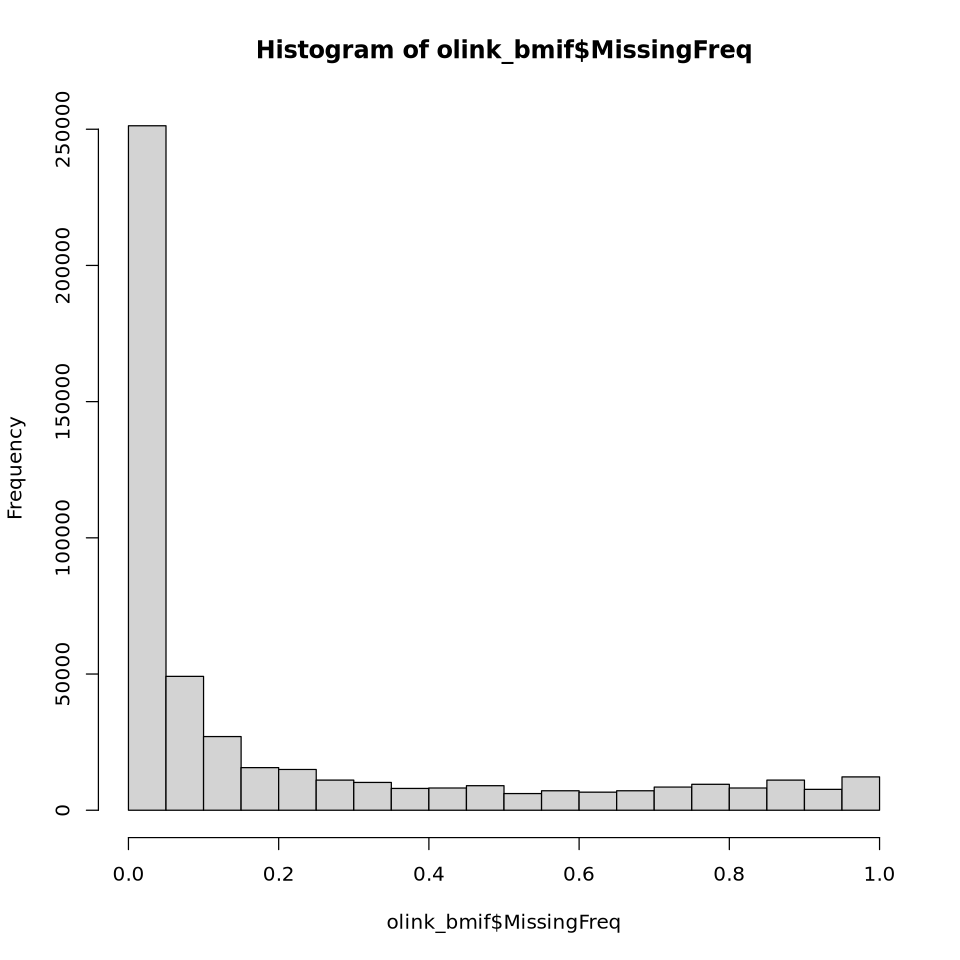

In [10]:
options(repr.plot.width = 8, repr.plot.height = 8)
hist(olink_bmif$MissingFreq)

missfreq.check.bool <- olink_bmif %>% group_by(Assay) %>% mutate(missfreq.constant.per.assay = MissingFreq %in% unique(MissingFreq)) %>% pull(missfreq.constant.per.assay)
paste0("MissingFreq is constant per assay: ", all(missfreq.check.bool))

### BM Panel

There are 8 panels in the BM data set. Below we examine the panels and ensure no biases in proteins represented across subjects.

In [11]:
unique(olink_bmif$Panel)

[1] "Oncology"           "Cardiometabolic_II" "Neurology_II"      
[4] "Inflammation"       "Cardiometabolic"    "Oncology_II"       
[7] "Neurology"          "Inflammation_II"

In [12]:
# ### Order Visit factor 
# ### into treatment visit orders
olink_bmif$VisitDetails = factor(olink_bmif$VisitDetails,
                          levels=c("MM Pre-Treatment","MM End Induction 1st Draw",
                                   "MM Post Transplant 90 Days","MM Post Transplant 1 year",
                                   "MM Post Transplant 2 year","Normal BMIF (Bridging Control)", "N/A - stand-alone collection",
                                  NA)
                          )
table(olink_bmif$Visit, useNA = 'always')



     MM End Induction 1st Draw      MM Post Transplant 1 year 
                         94176                          64746 
     MM Post Transplant 2 year     MM Post Transplant 90 Days 
                         29430                          82404 
              MM Pre-Treatment   N/A - stand-alone collection 
                        147150                           5886 
Normal BMIF (Bridging Control)                           <NA> 
                         64746                          11772 

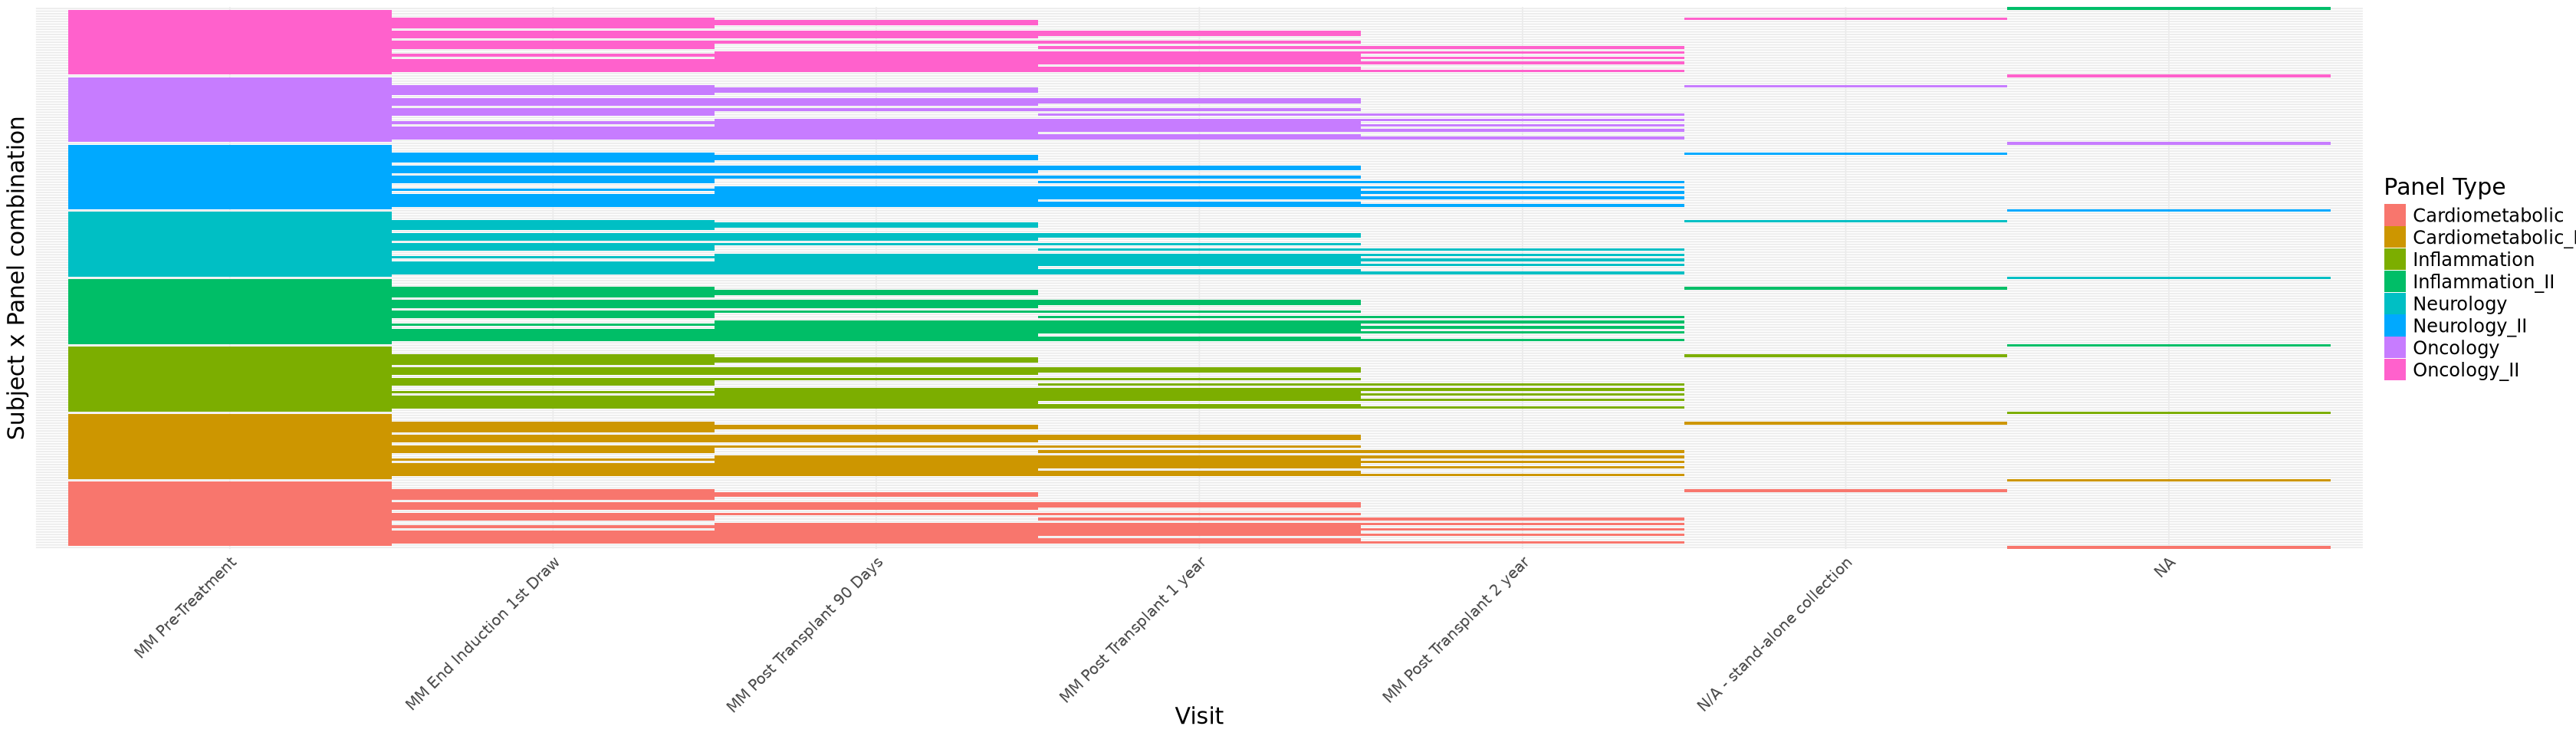

In [13]:
options(repr.plot.width = 28, repr.plot.height = 8)
ggplot(distinct(olink_bmif[, c('Subject','VisitDetails','Panel')]),
       aes(x = VisitDetails, y = interaction(Subject, Panel), fill = Panel)) + 
      geom_tile() + 
      theme_minimal() +
      labs(x = "Visit", y = "Subject x Panel combination", fill = "Panel Type")+
theme(text=element_text(size=18),
      axis.text.x = element_text(size=12,angle = 45, hjust = 1),
      axis.text.y = element_blank()
     ) # Improve label readability

In [14]:
### Here we confirm that the subjects that do not have a 'visit detail'
### are the samples from normal healthy donor from the All Cells cohort

### and control samples have NAs for cohort & visit 
table(olink_bmif$VisitDetails, olink_bmif$Cohort, useNA = 'always')
table(olink_bmif$Cohort, olink_bmif$is_technical_control, useNA='always')

                                
                                 AllCells    FH1   <NA>
  MM Pre-Treatment                      0 147150      0
  MM End Induction 1st Draw             0  94176      0
  MM Post Transplant 90 Days            0  82404      0
  MM Post Transplant 1 year             0  64746      0
  MM Post Transplant 2 year             0  29430      0
  Normal BMIF (Bridging Control)        0      0      0
  N/A - stand-alone collection          0   5886      0
  <NA>                              64746      0  11772

          
            FALSE   TRUE   <NA>
  AllCells  64746      0      0
  FH1      423792      0      0
  <NA>          0  11772      0

Looking at the patterns it can be seen that all panels has been used for all subjects at those visits that has been assayed. The important thing is that panels are balanced for each measurement. 

In [15]:
olink_bmif %>% 
  select(Assay, Panel) %>%
  distinct() %>%
  summarise(panel.n = n(), .by = Panel)  %>% t

Panel,Oncology,Cardiometabolic_II,Neurology_II,Inflammation,Cardiometabolic,Oncology_II,Neurology,Inflammation_II
panel.n,368,367,367,368,369,368,367,369


### BM Normalization

In [16]:
table(olink_bmif$Normalization, olink_bmif$Subject, useNA = "ifany") %>% t

        
         EXCLUDED Intensity Plate control
  AC1003     1518     63162            66
  FH1001      138      5742             6
  FH1002      690     28710            30
  FH1003      552     22968            24
  FH1004      414     17226            18
  FH1005      690     28710            30
  FH1006      552     22968            24
  FH1007      552     22968            24
  FH1008      552     22968            24
  FH1009      552     22968            24
  FH1010      138      5742             6
  FH1011      552     22968            24
  FH1012      276     11484            12
  FH1014      552     22968            24
  FH1015      138      5742             6
  FH1016      414     17226            18
  FH1017      552     22968            24
  FH1018      552     22968            24
  FH1019      138      5742             6
  FH1020      276     11484            12
  FH1021      414     17226            18
  FH1022      414     17226            18
  FH1023      414     172

It can be seen that almost all sampled are labeled to indicate they have been intensity normalized whereas some samples have been used for plate normalization. 

Warning message:
“Removed 11900 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


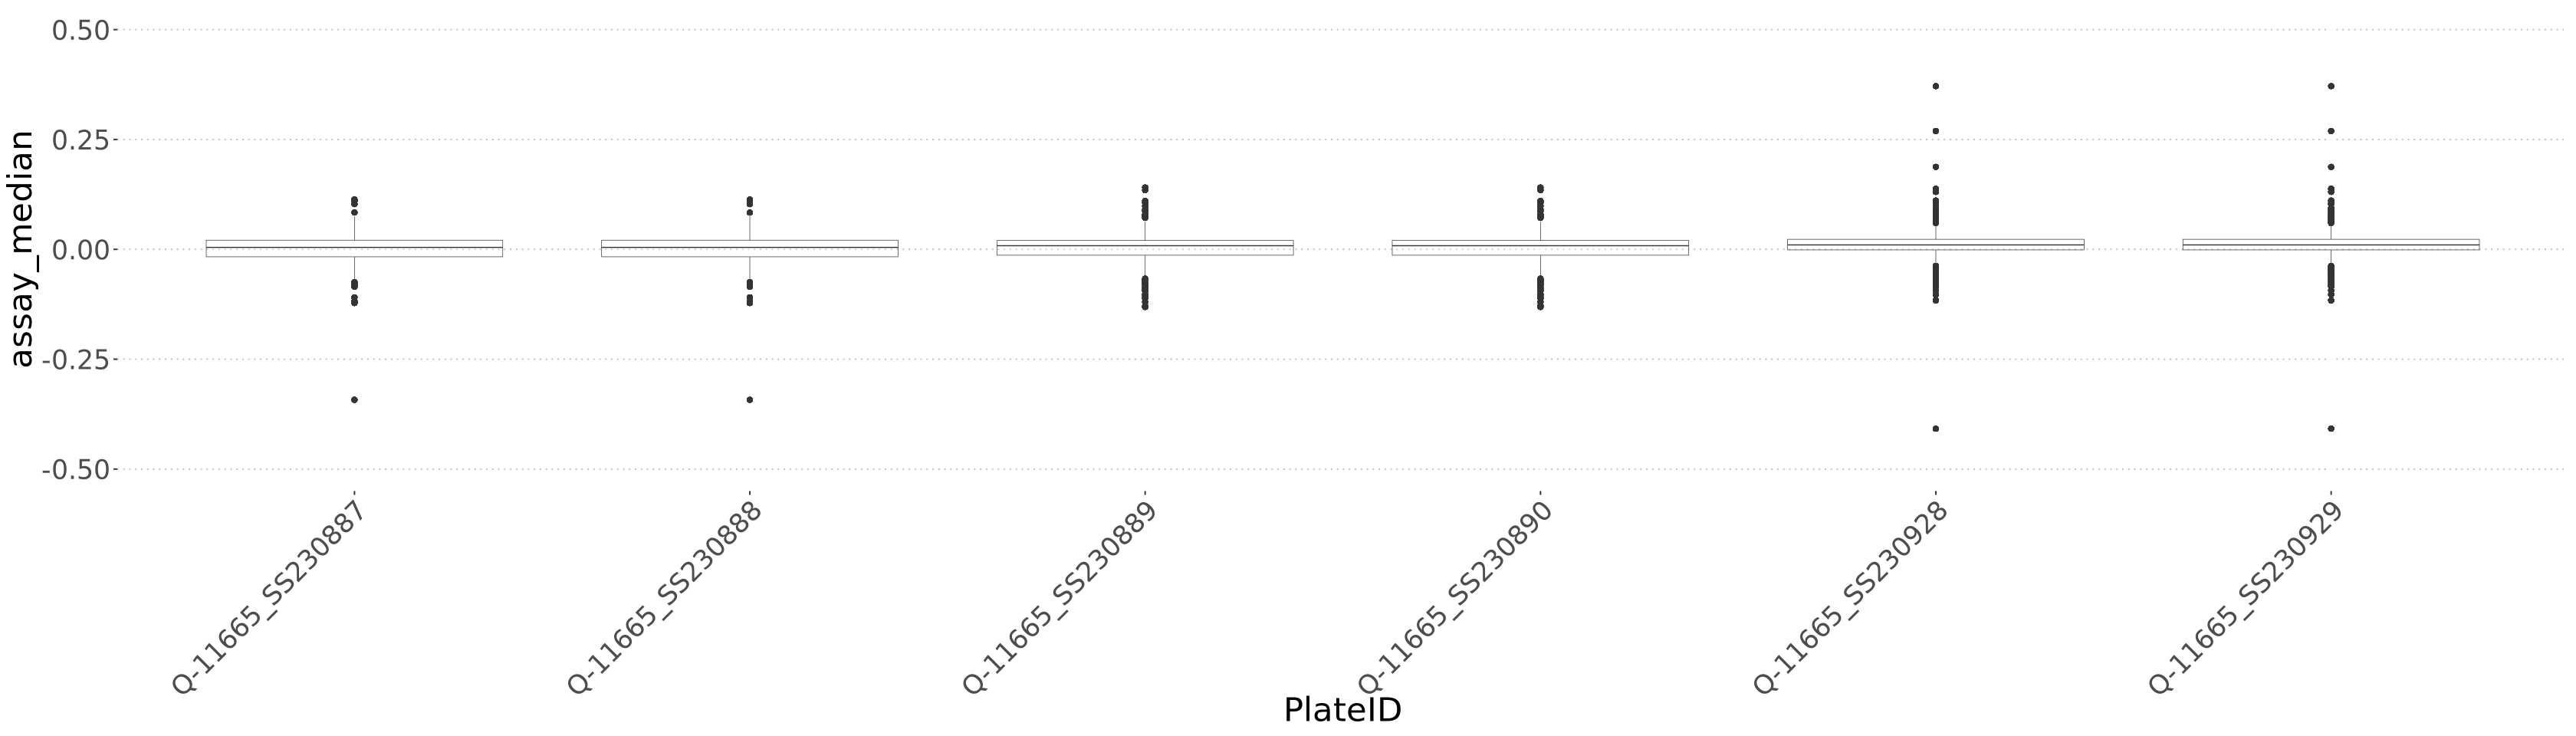

In [17]:
olink_bmif %>% mutate(global_median = median(NPX, na.rm = T)) %>% 
  group_by(PlateID) %>% 
  mutate(plate_median = median(NPX, na.rm=TRUE)) %>% 
  group_by(Assay) %>% 
  mutate(assay_median = median(NPX, na.rm=T)) %>% ungroup() %>%
  ggplot() + geom_boxplot(aes(x=PlateID, y=assay_median), size=0.2, alpha=0.2) + 
scale_y_continuous(limits = c(-0.5, 0.5)) + 
ggpubr::theme_pubclean() + theme(text=element_text(size=26),
                                 axis.text.x = element_text(angle=45, hjust=1))

Looking at the NPX values per plate the plates indeed seem to be aligned as expected after normalisation. 

In [18]:
structable(PlateID~Panel, data=olink_bmif)

                   PlateID Q-11665_SS230887 Q-11665_SS230888 Q-11665_SS230889 Q-11665_SS230890 Q-11665_SS230928 Q-11665_SS230929
Panel                                                                                                                           
Cardiometabolic                           0                0                0                0            31734            30996
Cardiometabolic_II                        0                0                0                0            31562            30828
Inflammation                          31648            30912                0                0                0                0
Inflammation_II                           0                0                0                0            31734            30996
Neurology                                 0                0                0                0            31562            30828
Neurology_II                              0                0            31562            30828   

### QC & Assay Warnings

Olink has QC_Warning and Assay_Warning as part of the standard file. Explore panels are NGS based, and QC_Warning is dependent on counts per sample. 

When checking the data, each sample has a unique value for QC_warning. The only exception is for the assays that are duplicated across plates. Assay Warning is issued if the median of triplicates are more than 5 SDs from the predefined values set for each assay. A low amount of assays have an assay warning (1606 out of ~500k), and were distributed across all visits. These were not removed from analyses. 

In [19]:
table(olink_bmif$AssayWarning)
structable(AssayWarning~Visit, data=olink_bmif)


EXCLUDED     PASS     WARN 
   11730   486974     1606 

                               AssayWarning EXCLUDED   PASS   WARN
Visit                                                             
MM End Induction 1st Draw                       2208  91664    304
MM Post Transplant 1 year                       1518  63046    182
MM Post Transplant 2 year                        690  28636    104
MM Post Transplant 90 Days                      1932  80224    248
MM Pre-Treatment                                3450 143198    502
N/A - stand-alone collection                     138   5720     28
Normal BMIF (Bridging Control)                  1518  63028    200

In [20]:
structable(AssayWarning~QC_Warning, data = olink_bmif)

            AssayWarning EXCLUDED   PASS   WARN
QC_Warning                                     
EXCLUDED                    11730      0      0
MANUAL_WARN                     0   1681      2
PASS                            0 477946   1599
WARN                            0   7347      5

In [21]:
table(olink_bmif$SampleFormat, useNA= "always")


  BMIF   <NA> 
488538  11772 

### Note on IG-Depleted and Non-Depleted Samples

Sample type is exclusively Ig Depleted and Ig Non Depleted for cases. Among normal bone marrow controls, several control samples are present. The Ig depletion was with beads that bind to Fc Ig and then magnetically sorted. The BMIF spike in is normal samples with spiked in beads to test that remnant beads in the samples does not have an independen effect of their depletion. 

The high bead match is a normal sample that was treated with beads in the same concentration as the myeloma sample with the highest bead volume (5ml bead solution on 17 microliter of myeloma). BC are internal bridge controls to account for differences in processing across different days. Additional analyses (not shown) indicated that IG-depleted samples were not to be used, and they are excluded in the last section of this notebook. 

**Supernatant and BMIF are the same. BMIF was just a later designation.**

NM matched with SUP[number] means that it is a normal bone marrow that received tha same amount of beads as the corresponding myeloma bone marrow sample. 



In [22]:
data.frame(table(olink_bmif$`Sample Type`, olink_bmif$Visit))

Var1,Var2,Freq
<fct>,<fct>,<int>
BC 09/21/23 Ig Depleted,MM End Induction 1st Draw,0
BC 09/21/23 Ig Non depleted,MM End Induction 1st Draw,0
BC 09/22/23 Ig Depleted,MM End Induction 1st Draw,0
BC 09/22/23 Ig Non depleted,MM End Induction 1st Draw,0
BC 10/06/23 Ig Depleted,MM End Induction 1st Draw,0
BC 10/06/23 Ig Non depleted,MM End Induction 1st Draw,0
BC 10/19/23 Ig Depleted,MM End Induction 1st Draw,0
BC 10/19/23 Ig Non depleted,MM End Induction 1st Draw,0
BC 10/20/23 Ig Depleted,MM End Induction 1st Draw,0


AC1003 is the name for the subject that contributed normal bone marrow and therefore does not have a 'visit id name' 

### Cohort, BM Subject, Visit & sampleKitGuid

Subject identifies cases and the one sample used for normal bone marrow as control. One subject participates in the standalone collection. The NA correspons to the control samples.  One patient has a visit that is NA - standalone collection. That subject has also contributed bone marrow for pre-treatment and end induction. 

Only one person (FH1023) contributed to the visit NA - Standalone collection. 

Only FH1 MM subjects have a kitGuid. We have 58 unique samples, and these represent both IG and non IG . All procedure related controls on normal bone marrow, have the same kitguid (6062). 

In [23]:
olink_bmif %>% group_by(Subject) %>% summarise(unique_visits = n_distinct(VisitDetails))  %>% t
olink_bmif %>% filter(Subject == "AC1003") %>% pull(Visit) %>% unique()
olink_bmif %>% filter(str_detect(SampleID, "CONTROL")) %>% pull(Visit) %>% unique()
length(unique(olink_bmif$sample.sampleKitGuid))

Subject,AC1003,FH1001,FH1002,FH1003,FH1004,FH1005,FH1006,FH1007,FH1008,FH1009,⋯,FH1018,FH1019,FH1020,FH1021,FH1022,FH1023,FH1024,FH1026,FH1027,NA
unique_visits,1,1,5,4,3,5,4,4,4,4,⋯,4,1,2,3,3,3,1,1,1,1


[1] "Normal BMIF (Bridging Control)"

[1] NA

[1] 19

The cohort variable has samples for a healthy donor ('AllCells'), our FH1 oncology subjects, and an NA value for healthy donors. The table below indicates that subjects without a MM treatment visit belong to either the healthy donor or technical controls. 

In [25]:
table(olink_bmif$Cohort, olink_bmif$VisitDetails, useNA = 'always') %>% t

                                
                                 AllCells    FH1   <NA>
  MM Pre-Treatment                      0 147150      0
  MM End Induction 1st Draw             0  94176      0
  MM Post Transplant 90 Days            0  82404      0
  MM Post Transplant 1 year             0  64746      0
  MM Post Transplant 2 year             0  29430      0
  Normal BMIF (Bridging Control)        0      0      0
  N/A - stand-alone collection          0   5886      0
  <NA>                              64746      0  11772

# Check Column Names

Column names are first renamed to the common scheme of camelCase. Some columns from different sources are identical entities, such as subject and subjectGuid. These are renamed to a common name in the final script where the names across bone marrow & plasma are aligned. 

In [26]:
colnames(olink_bmif)

[1] "SampleID"             "Index"                "OlinkID"             
 [4] "UniProt"              "Assay"                "MissingFreq"         
 [7] "Panel"                "PanelLotNr"           "PlateID"             
[10] "QC_Warning"           "LOD"                  "NPX"                 
[13] "Normalization"        "AssayWarning"         "ExploreVersion"      
[16] "Cohort"               "Subject"              "Sex"                 
[19] "VisitName"            "VisitDetails"         "DaysSinceFirstVisit" 
[22] "SampleKitGuid"        "is_technical_control" "SampleFormat"        
[25] "Sample Type"          "Age"                  "Race"                
[28] "Visit"                "CollectionDate"       "YearGroup"           
[31] "LocationBarcode"      "LocatedAtRow"         "LocatedAtColumn"     
[34] "Volume"               "specimenType"         "sample.sampleKitGuid"

In [27]:
### Remove following columns that are no 
### long used in this analysis 
olink_bmif_clean <- olink_bmif[, !colnames(olink_bmif) 
                               %in%  c('SampleType',  #constant either sample or control
                                       'Index', # numeric value from saving to csv
                                       'PanelLotNr',
                                       'PlateID', # indicates plate 1 or 2
                                       'ExploreVersion',  #constant value of 2011-03-08 
                                       'YearGroup', # administrative detail
                                       'LocationBarcode', #olink plate details
                                       'LocatedAtRow',  #olink plate details
                                       'LocatedAtColumn', #olink plate details
                                       'Volume', #constant 50 uL
                                       'specimenType', # constant BMIF
                                       'sample.sampleKitGuid') #duplicate with SampleKitGuid column
                              ]
dim(olink_bmif)
dim(olink_bmif_clean)              

[1] 500310     36

[1] 500310     25

# Filter All Cells and IG Depleted Samples

In this section we remove samples associated with the following:

- All Cells = 'single heathy donor not used in future analyses
- Control Samples = used for plate normalization and no longer used elsewhere
- IG Depleted Samples = not used due to technical challenges.  

Here we write final Bone Marrow Data file to CSV, and this final bone marrow object is then used in the final script where the samples and column names between plasma & bone marrow are aligned. 

In [29]:
dim(olink_bmif_clean)

### Remove the healthy bone marrow samples 
olink_bmif_clean <- olink_bmif_clean[olink_bmif_clean$Cohort !='AllCells',]
dim(olink_bmif_clean)

### remove the Control Samples
#table(olink_bmif_clean$)
olink_bmif_clean <- olink_bmif_clean[ olink_bmif_clean$is_technical_control==F & !is.na(olink_bmif_clean$is_technical_control),]
dim(olink_bmif_clean)

### remove the IG-depleted samples 
olink_bmif_clean <- olink_bmif_clean[olink_bmif_clean$`Sample Type` !='Ig Depleted',]
dim(olink_bmif_clean)


[1] 500310     25

[1] 435564     25

[1] 423792     25

[1] 211896     25

### Write Typed and cleaned BM file to private folder

In [30]:
file.name <- "Olink_BM_with_hise_descriptors_08-18-2025.csv"
data.output.path <- file.path("../Data", file.name)
write_excel_csv(olink_bmif_clean, data.output.path)

In [32]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/olink/lib/libopenblasp-r0.3.27.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] magrittr_2.0.3     patchwork_1.2.0    data.table_1.17.8  ggpubr_0.6.1      
 [5] lme4_1.1-35.5      Matrix_1.6-5       OlinkAnalyze_4.3.1 vcd_1.4-13        
 [9] lubridate_1.9.3    forcats_1.0.0      stringr_1.5.1      dplyr_1.1.4       
[13] purrr_1.1.0        readr_2.1.5        tidyr_1.3.1   